# LERG duty-cycle: Bayesian RLF fit -> network-centrality discrimination

1. **Bayesian fit** of the Kondapally+22 LERG RLF (0.5 < z < 1) with the
   mass-dependent (power-law) duty cycle, via dynamical nested sampling.
2. From the posterior, take two parameter sets the RLF *cannot* tell apart: the
   **MAP / best fit** and an **edge-of-confidence** point on the Delta(-2lnL)=4
   shell with the largest deviation in the mean duty cycle.
3. Build **lightcones** and generate a LERG position sample for each set.
4. Compute **network centralities**, their CDFs, and the mean +/- std scatter
   across lightcones to test whether the spatial statistics break the RLF
   degeneracy that leaves these two parameter sets equally acceptable.

Model + likelihood live in `radiogalaxies_duty_ref.py` and `rlf_fit_ref.py`.

In [1]:
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import matplotlib.pyplot as plt
from time import time
from astropy.cosmology import FlatLambdaCDM

import radiogalaxies_duty_ref as rgd
import rlf_fit_ref as rf
import generate_network as gn

%load_ext autoreload
%autoreload 2

## 1. Configuration

In [2]:
# cosmology (matches Kondapally+22: flat LCDM, Om=0.3, H0=70)
h = 0.7
cosmo = FlatLambdaCDM(H0=100 * h, Om0=0.3)

# paths
path_to_cat1 = 'Euclid_flagship/26067.parquet'
obs_path     = 'AGN_LF_Kondapally22/LERG/LF_LERG_AGN_0.5_z_1.0_tab_quies.csv'

# redshift bin of the RLF / host sample
z_min, z_max = 0.5, 0.99

# host (red central) stellar-mass range
logM_lo, logM_hi = 10.0, 12.5

# fitting patch (one sky region used only to fit the RLF)
fit_ra  = (135, 165)
fit_dec = (0, 5)

# shared model bookkeeping
logMcut     = 10.5
sigma_logL  = 0.5
logmnorm    = 11.0

# lightcones for the network stage: RA sub-boxes x two Dec stripes
ra_edges   = np.arange(145, 186, 5)
ra_ranges  = list(zip(ra_edges[:-1], ra_edges[1:]))
dec_slices = [(0, 5), (5, 10)]   # model 1 -> dec 0-5,  model 2 -> dec 5-10

# network / centralities
linkinglength = 8
centralities  = ['degree', 'harmonic']
min_nodes     = 100
n_jobs        = 8     # processes for the per-lightcone network build (section 7)

## 2. Load the observed RLF and the Flagship catalogue

In [3]:
obs = rf.load_kondapally(obs_path)
print('n_bins =', obs['n_bins'], ' lum range =', round(obs['lum_min'], 2), '-', round(obs['lum_max'], 2))

n_bins = 11  lum range = 23.4 - 26.7


/home/homo-novus/Documents/network_analysis/X_mas_tree/rlf_fit_ref.py:30: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


In [4]:
dataset = ds.dataset(path_to_cat1)
table = dataset.to_table()
cat = table.to_pandas(split_blocks=True, self_destruct=True)
try: 
    del dataset, table
except Exception as e:
    print(e)
    
print('catalogue rows:', len(cat))

catalogue rows: 34665494


## 3. Fitting patch and comoving volume

Red (`color_kind == 0`) centrals (`kind == 0`) in the RLF redshift bin. Volume in
**Mpc^3** to match Kondapally's Mpc^-3 (h = 0.7); do **not** multiply by `h**3`
or model densities become h^3 Mpc^-3. Positions stay in Mpc/h for the network step.

In [5]:
def lc_volume(z_lo, z_hi, solid_angle, cosmology):
    dc_lo = cosmology.comoving_distance(z_lo).value
    dc_hi = cosmology.comoving_distance(z_hi).value
    return solid_angle / 3.0 * (dc_hi**3 - dc_lo**3)   # Mpc^3

fit_patch = cat.query(
    f"{fit_ra[0]} <= ra_gal < {fit_ra[1]} and {fit_dec[0]} <= dec_gal < {fit_dec[1]} "
    f"and {z_min} <= true_redshift_gal <= {z_max} "
    f"and {logM_lo} < log_stellar_mass < {logM_hi} and kind == 0 and color_kind == 0"
).copy()

sim_data = fit_patch[['log_stellar_mass', 'x_gal', 'y_gal', 'z_gal']].to_numpy(dtype='float64')

solid_angle = (np.radians(fit_ra[1]) - np.radians(fit_ra[0])) * (
    np.sin(np.radians(fit_dec[1])) - np.sin(np.radians(fit_dec[0])))
V = lc_volume(z_min, z_max, solid_angle, cosmo)
print(f"N_hosts = {len(sim_data)}   V = {V:.3e} Mpc^3")

N_hosts = 259678   V = 4.340e+08 Mpc^3


## 4. Bayesian analysis of the radio LF (dynamical nested sampling)

Sample the posterior of the mass-dependent (power-law) duty cycle against the
Kondapally+22 RLF with `dynesty`. This replaces the earlier chi2 minimisation and
gives the full posterior needed for the MAP + edge-of-confidence selection.

- The chi2 surface is made **deterministic** by fixing the resim seed (`NS_SEED`).
- A fork `multiprocessing.Pool` with *top-level* `loglike`/`prior_transform` is used
  (`dynesty.pool.Pool` forces `spawn`, which can't see notebook-cell functions).
- `sample='rwalk'` is dynesty's recommendation for this >3-D degenerate posterior.

**Runtime:** nested sampling over a stochastic likelihood is the slow step (tens of
minutes at `nlive_init=500`). For a quick look drop `nlive_init` to ~250 / lower
`NS_RESIM`.

In [6]:
import multiprocessing as mp
import dynesty
from dynesty import utils as dyfunc

# --- what to sample (default: the mass-dependent power-law duty cycle) -------
NS_NAMES  = ['duty_D0', 'duty_beta', 'lognormR', 'alphaR']
NS_FIXED  = {'duty_pivot': logmnorm, 'sigma_logL': sigma_logL, 'logmnorm': logmnorm}
NS_BOUNDS = {                       # uniform-prior (lo, hi) for any free parameter
    'duty_cycle': (0.0, 1.0),
    'duty_D0':    (0.0, 2.0),       # duty cycle at the pivot mass (clip handles >1)
    'duty_beta':  (0.0, 5.0),       # mass slope; >0 -> massive hosts more active
    'lognormR':   (22.0, 26.0),     # log L normalisation at logmnorm
    'alphaR':     (0.0, 6.0),       # L-M slope
}
NS_RESIM  = 4        # realisations averaged per likelihood call
NS_SEED   = 7         # FIXED -> deterministic chi2 surface (NS assumes no noise)

_ns_lo = np.array([NS_BOUNDS[p][0] for p in NS_NAMES])
_ns_hi = np.array([NS_BOUNDS[p][1] for p in NS_NAMES])

# Top-level (not closures) so a fork multiprocessing.Pool can pickle them by name.
def prior_transform(u):
    return _ns_lo + u * (_ns_hi - _ns_lo)

def loglike(theta):
    kw = dict(zip(NS_NAMES, theta)); kw.update(NS_FIXED)
    _, y_pred = rf.rlf_binned(sim_data, V, obs['lum_min'], obs['lum_max'],
                              obs['n_bins'], n_resim=NS_RESIM, seed=NS_SEED,
                              logMcut=logMcut, **kw)
    chi2 = rf.chi2_asym(y_pred, obs['y'], obs['yerr_up'], obs['yerr_down'])
    return -0.5 * chi2 if np.isfinite(chi2) else -1e10

print('sampling', NS_NAMES, '| fixed', list(NS_FIXED))

sampling ['duty_D0', 'duty_beta', 'lognormR', 'alphaR'] | fixed ['duty_pivot', 'sigma_logL', 'logmnorm']


In [7]:
NPROC = 12        # set to 1 to run serial
t0 = time()

# 'rwalk' (random-walk) sampling: dynesty recommends it over the default
# uniform/multi-ellipsoid for this >3-D, mildly degenerate posterior (the default
# triggers a "bootstrap enlargement factor very large -> inefficient" warning here).
# Quick look: drop nlive_init to ~250. Tighter posterior: raise NS_RESIM.
pool = mp.Pool(NPROC) if NPROC > 1 else None     # default fork ctx inherits globals
try:
    dsampler = dynesty.NestedSampler(
        loglike, prior_transform, nlive=250, ndim=len(NS_NAMES),
        pool=pool, queue_size=NPROC, sample='rwalk')
    dsampler.run_nested( print_progress=True)
finally:
    if pool is not None:
        pool.close(); pool.join()

res_ns = dsampler.results
w_ns   = res_ns.importance_weights()
post   = dyfunc.resample_equal(res_ns.samples, w_ns)   # equal-weight posterior
q16, q50, q84 = np.percentile(post, [16, 50, 84], axis=0)

print(f"\nran in {time() - t0:.0f}s   ({len(res_ns.samples)} samples)")
print(f"logZ = {res_ns.logz[-1]:.2f} +/- {res_ns.logzerr[-1]:.2f}")
for k, p in enumerate(NS_NAMES):
    print(f"  {p:10s} = {q50[k]:8.3f}  (+{q84[k]-q50[k]:.3f} / -{q50[k]-q16[k]:.3f})")

# posterior-median model, ready to drop into `pars` (section 7) for comparison
best_ns = {**{p: float(q50[k]) for k, p in enumerate(NS_NAMES)}, **NS_FIXED}
best_ns

3835it [15:44,  4.06it/s, +250 | bound: 12 | nc: 1 | ncall: 81408 | eff(%):  5.033 | loglstar:   -inf < -33.494 <    inf | logz: -47.531 +/-  0.213 | dlogz:  0.001 >  0.259]



ran in 948s   (4085 samples)
logZ = -47.53 +/- 0.27
  duty_D0    =    1.647  (+0.246 / -0.294)
  duty_beta  =    0.519  (+0.464 / -0.353)
  lognormR   =   23.723  (+0.023 / -0.024)
  alphaR     =    4.231  (+0.093 / -0.114)


{'duty_D0': 1.6473344085480397,
 'duty_beta': 0.5192750493491858,
 'lognormR': 23.723068979294027,
 'alphaR': 4.230704037430272,
 'duty_pivot': 11.0,
 'sigma_logL': 0.5,
 'logmnorm': 11.0}

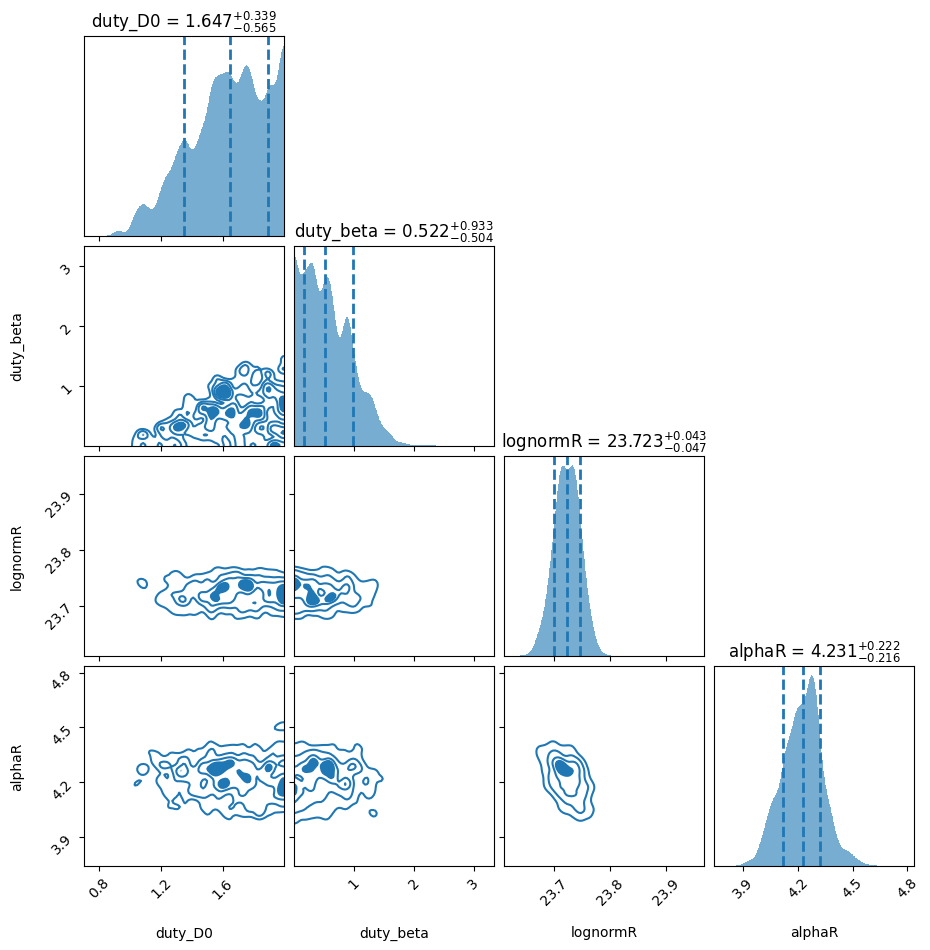

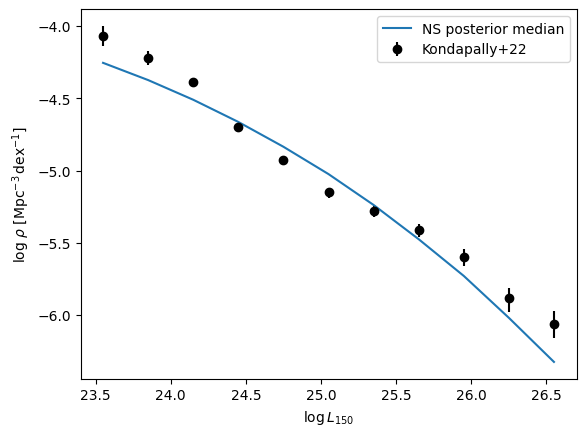

In [8]:
from dynesty import plotting as dyplot

# posterior corner plot (dynesty built-in: cornerplot consumes the
# importance-weighted results object directly, so the equal-weight `post`
# resampling is not needed for the plot itself)
fig, axes = dyplot.cornerplot(res_ns, labels=NS_NAMES,
                              quantiles=[0.16, 0.5, 0.84],
                              show_titles=True, title_fmt='.3f',
                              color='C0', max_n_ticks=4)
plt.show()

# posterior-median model vs the observed RLF
plt.errorbar(obs['logL'], obs['y'], yerr=[obs['yerr_down'], obs['yerr_up']],
             fmt='o', color='k', label='Kondapally+22')
b, m = rf.rlf_binned(sim_data, V, obs['lum_min'], obs['lum_max'], obs['n_bins'],
                     n_resim=64, logMcut=logMcut, **best_ns)
plt.plot(b, m, label='NS posterior median')
plt.xlabel(r'$\log L_{150}$'); plt.ylabel(r'$\log\,\rho\ [\mathrm{Mpc^{-3}\,dex^{-1}}]$')
plt.legend(); plt.show()

## 5. Best-fit (MAP) and edge-of-confidence parameter sets

With uniform priors the **MAP** is the maximum-likelihood sample (minimum -2 lnL).
The **edge-of-confidence** set is the posterior sample on the Delta(-2lnL)=4 shell
(~2 sigma fit-quality boundary, lnL >= lnL_max - 2) whose **mean duty cycle**
deviates most from the MAP. Both fit the RLF about equally well; the network stage
asks whether their *spatial* statistics differ.

Mean duty cycle = <f(M)> over the eligible hosts, with f the power-law
`duty_powerlaw`. These two parameter dicts become `pars` for the lightcone stage.

shell: 21 / 4085 samples within Delta(-2lnL) <= 4
-2lnL_min = 66.99
  MAP : {'duty_D0': 1.601024676317655, 'duty_beta': 0.8773945079241978, 'lognormR': 23.734437363128652, 'alphaR': 4.187450266542945, 'duty_pivot': 11.0, 'sigma_logL': 0.5, 'logmnorm': 11.0}
  edge: {'duty_D0': 1.9087999334768513, 'duty_beta': 0.7080177628636444, 'lognormR': 23.72303479586998, 'alphaR': 4.191422086891046, 'duty_pivot': 11.0, 'sigma_logL': 0.5, 'logmnorm': 11.0}   (-2lnL = 68.66)


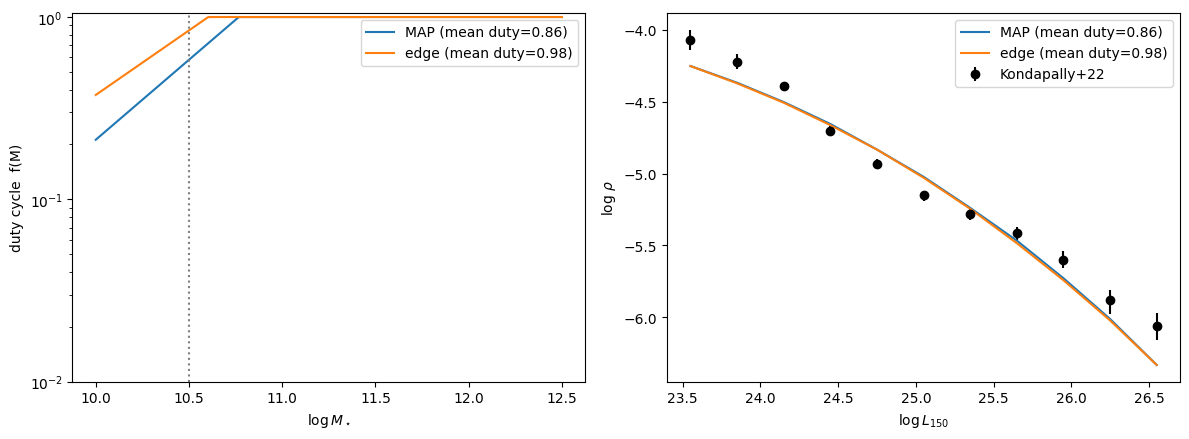

In [9]:
# per-sample log-likelihood from the nested run (uniform priors -> MAP = max L)
logl = res_ns.logl
imap = int(np.argmax(logl))
theta_map = res_ns.samples[imap]

# Delta(-2 lnL) <= 4  <=>  lnL >= lnL_max - 2   (~2 sigma fit-quality shell)
shell       = logl >= (logl[imap] - 1.0)
shell_theta = res_ns.samples[shell]
shell_logl  = logl[shell]

# scalar duty cycle per sample = mean activation prob over the eligible hosts
logM_elig = sim_data[sim_data[:, 0] > logMcut, 0]
iD0, ibeta = NS_NAMES.index('duty_D0'), NS_NAMES.index('duty_beta')

def mean_duty(theta):
    return float(rgd.duty_powerlaw(logM_elig, theta[iD0], theta[ibeta], logmnorm).mean())

fbar_map   = mean_duty(theta_map)
fbar_shell = np.array([mean_duty(t) for t in shell_theta])
idev       = int(np.argmax(np.abs(fbar_shell - fbar_map)))   # max duty deviation
theta_dev  = shell_theta[idev]

def to_pars(theta):
    return {**{p: float(theta[k]) for k, p in enumerate(NS_NAMES)}, **NS_FIXED}

pars_map = to_pars(theta_map)
pars_dev = to_pars(theta_dev)
pars     = [pars_map, pars_dev]
labels   = [f'MAP (mean duty={fbar_map:.2f})',
            f'edge (mean duty={mean_duty(theta_dev):.2f})']

print(f'shell: {int(shell.sum())} / {len(logl)} samples within Delta(-2lnL) <= 4')
print(f'-2lnL_min = {-2 * logl[imap]:.2f}')
print(f'  MAP : {pars_map}')
print(f'  edge: {pars_dev}   (-2lnL = {-2 * shell_logl[idev]:.2f})')

# both parameter sets: duty-cycle curve f(M) and the RLF (should fit comparably)
mgrid = np.linspace(logM_lo, logM_hi, 200)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))
for p, lab in zip(pars, labels):
    axL.plot(mgrid, rgd.duty_powerlaw(mgrid, p['duty_D0'], p['duty_beta'], logmnorm), label=lab)
axL.axvline(logMcut, ls=':', color='grey'); axL.set_ylim(0, 1.05)
axL.set_xlabel(r'$\log M_\star$'); axL.set_ylabel('duty cycle  f(M)'); axL.legend()
axL.set_yscale('log')
axL.set_ylim(0.01,1.05)

axR.errorbar(obs['logL'], obs['y'], yerr=[obs['yerr_down'], obs['yerr_up']],
             fmt='o', color='k', label='Kondapally+22')
for p, lab in zip(pars, labels):
    b, m = rf.rlf_binned(sim_data, V, obs['lum_min'], obs['lum_max'], obs['n_bins'],
                         n_resim=32, logMcut=logMcut, **p)
    axR.plot(b, m, label=lab)
axR.set_xlabel(r'$\log L_{150}$'); axR.set_ylabel(r'$\log\,\rho$'); axR.legend()
plt.tight_layout(); plt.show()

## 6. Generate LERG positions in the lightcones

Each parameter set gets its own Dec stripe; within it, every RA sub-box is one
lightcone. We keep the comoving (x, y, z) of the active LERGs. `stochastic_agn_catalog`
dispatches on the keys in each `pars` dict, so both the MAP and edge sets go through
the same call.

In [10]:
points_dict = {}
for i, (dec_min, dec_max) in enumerate(dec_slices, start=1):
    p = pars[i - 1]
    points_arr = []
    for ra_lo, ra_hi in ra_ranges:
        seed = int(time() * 1000) % (2**32)
        sub_cat = cat.query(
            f"{ra_lo} <= ra_gal < {ra_hi} and {dec_min} <= dec_gal < {dec_max} "
            f"and {z_min} <= true_redshift_gal <= {z_max} "
            f"and {logM_lo} < log_stellar_mass < {logM_hi} and color_kind == 0 and kind == 0"
        )
        subbox = sub_cat[['log_stellar_mass', 'x_gal', 'y_gal', 'z_gal']].to_numpy(dtype='float64')
        if len(subbox) == 0:
            continue
        result = rgd.stochastic_agn_catalog(data=subbox, seed=seed, logMcut=logMcut, **p)
        points_arr.append(result['agn_catalog'][:, [1, 2, 3]])   # x, y, z (comoving)
    points_dict[f'pars_{i}'] = points_arr

{f'pars_{i} ({labels[i-1]})': (len(v), int(np.mean([len(a) for a in v])) if v else 0)
 for i, v in [(1, points_dict['pars_1']), (2, points_dict['pars_2'])]}

{'pars_1 (MAP (mean duty=0.86))': (8, 22712),
 'pars_2 (edge (mean duty=0.98))': (8, 25489)}

## 7. Network centralities per lightcone (parallelised)

The per-lightcone work (build the linking-length graph, compute node metrics) is
independent across lightcones, so we farm it out over a fork `multiprocessing.Pool`
(`n_jobs` workers). `_lightcone_metrics` is top-level so fork workers can pickle it.

In [11]:
# per-lightcone build + metrics, independent across lightcones -> parallelise
def _lightcone_metrics(args):
    pts, ll = args
    G = gn.generate_network(pts, ll)
    return gn.compute_node_metrics(G)

node_metrics_dict = {}
with mp.Pool(n_jobs) as pool:
    for i in [1, 2]:
        tasks = [(pts, linkinglength) for pts in points_dict[f'pars_{i}']]
        node_metrics_dict[f'pars_{i}'] = pool.map(_lightcone_metrics, tasks)

print('lightcones per parameter set:', {k: len(v) for k, v in node_metrics_dict.items()})

lightcones per parameter set: {'pars_1': 8, 'pars_2': 8}


## 8. Centrality CDFs (skip sparse lightcones)

In [12]:
cdf_dict = {}
for centrality in centralities:
    per_model = {}
    for i in [1, 2]:
        arr = []
        for df in node_metrics_dict[f'pars_{i}']:
            if len(df) < min_nodes:
                continue
            cdf, bin_edges = gn.centrality_cdf(df, centrality)
            arr.append((bin_edges, cdf))
        per_model[f'pars_{i}'] = arr
    cdf_dict[centrality] = per_model

## 9. Mean +/- std of the CDFs across lightcones

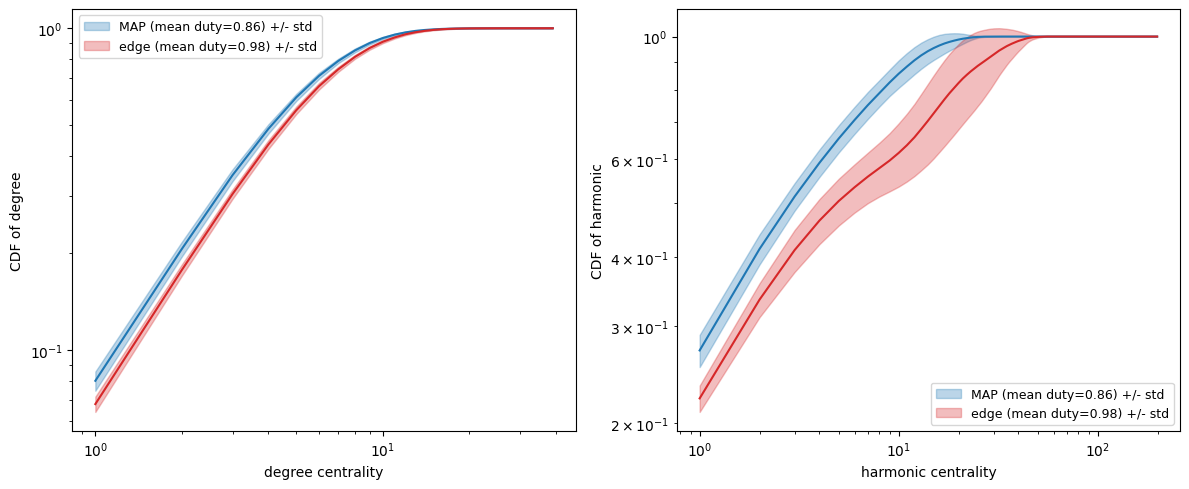

In [13]:
colors = ['tab:blue', 'tab:red']
fig, axs = plt.subplots(1, len(centralities), figsize=(6 * len(centralities), 5))
axs = np.atleast_1d(axs)

for j, centrality in enumerate(centralities):
    ax = axs[j]
    for i in [1, 2]:
        sample = cdf_dict[centrality][f'pars_{i}']
        if not sample:
            continue
        x = sample[0][0][1:]
        cdfs = np.array([c for (_, c) in sample])
        mean_cdf, std_cdf = cdfs.mean(axis=0), cdfs.std(axis=0)
        ax.fill_between(x, mean_cdf - std_cdf, mean_cdf + std_cdf,
                        color=colors[i - 1], alpha=0.3, label=f"{labels[i-1]} +/- std")
        ax.plot(x, mean_cdf, color=colors[i - 1], lw=1.5)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(f'{centrality} centrality'); ax.set_ylabel(f'CDF of {centrality}')
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 10. CDF difference between the two parameter sets (discriminating statistic)

Combined scatter `sqrt(std_1^2 + std_2^2)`; the separation score sums
`(mean_diff / combined_std)^2` over the well-sampled bins. A large score means the
MAP and edge-of-confidence duty cycles - which the RLF cannot separate - ARE
distinguishable by this centrality.

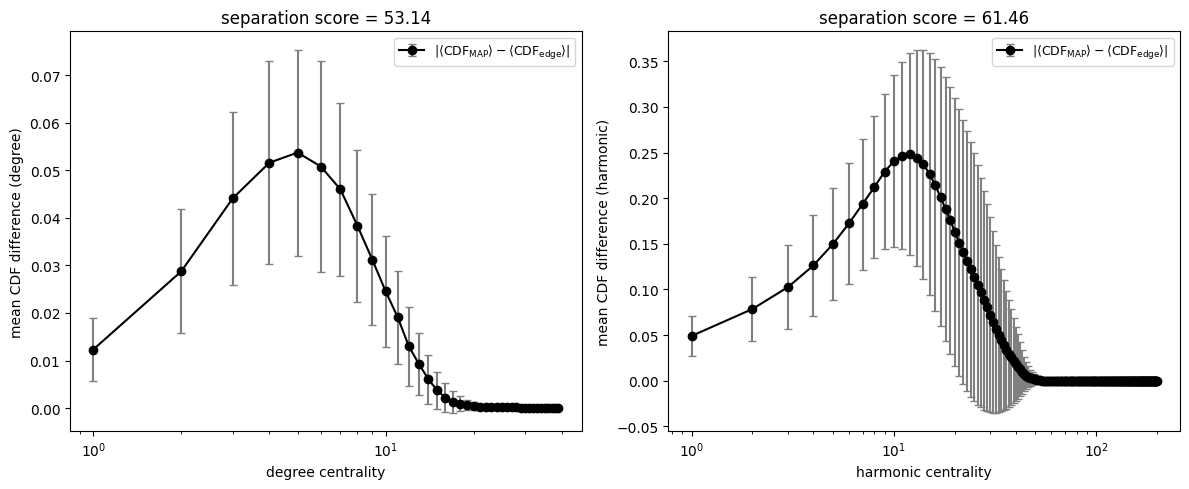

In [14]:
fig, axs = plt.subplots(1, len(centralities), figsize=(6 * len(centralities), 5))
axs = np.atleast_1d(axs)

for j, centrality in enumerate(centralities):
    ax = axs[j]
    s1 = cdf_dict[centrality]['pars_1']
    s2 = cdf_dict[centrality]['pars_2']
    if not s1 or not s2:
        continue
    x = s1[0][0][1:]
    c1 = np.array([c for (_, c) in s1])
    c2 = np.array([c for (_, c) in s2])
    mean_diff = np.abs(c1.mean(axis=0) - c2.mean(axis=0))
    combined_std = np.sqrt(c1.std(axis=0)**2 + c2.std(axis=0)**2)
    ax.errorbar(x, mean_diff, yerr=combined_std, fmt='o-', color='black',
                ecolor='gray', capsize=3,
                label=r'$|\langle\mathrm{CDF}_{\rm MAP}\rangle-\langle\mathrm{CDF}_{\rm edge}\rangle|$')
    n = min(10, len(x))
    sep = np.nansum(mean_diff[:n]**2 / (combined_std[:n]**2 + 1e-12))
    ax.set_xscale('log')
    ax.set_xlabel(f'{centrality} centrality')
    ax.set_ylabel(f'mean CDF difference ({centrality})')
    ax.set_title(f'separation score = {sep:.2f}')
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## Appendix. Bayesian evidence: is mass-dependence warranted? (optional)

Independent of the network analysis: sample BOTH the constant and power-law duty
cycles and compare evidences, `Delta lnZ = lnZ_powerlaw - lnZ_constant`, on the
Kass & Raftery (1995) scale. NOTE: `run_nested` overwrites the section-4 config
globals (`NS_NAMES`, `NS_FIXED`), so re-run sections 4-5 before redoing the main
flow after this.

In [15]:
def run_nested(names, fixed, *, nlive=250, sample='rwalk', nproc=8):
    """Nested-sample one duty-cycle model. Rewrites the shared config globals that
    the top-level loglike/prior_transform read, THEN forks the pool so its workers
    inherit this model's parameter set. Returns logZ + the equal-weight posterior."""
    global NS_NAMES, NS_FIXED, _ns_lo, _ns_hi
    NS_NAMES = list(names)
    NS_FIXED = dict(fixed)
    _ns_lo = np.array([NS_BOUNDS[p][0] for p in NS_NAMES])
    _ns_hi = np.array([NS_BOUNDS[p][1] for p in NS_NAMES])

    t0 = time()
    pool = mp.Pool(nproc) if nproc > 1 else None
    try:
        ds = dynesty.NestedSampler(loglike, prior_transform, nlive=nlive,
                                   ndim=len(NS_NAMES), pool=pool,
                                   queue_size=nproc, sample=sample)
        ds.run_nested(print_progress=True)
    finally:
        if pool is not None:
            pool.close(); pool.join()
    res = ds.results
    post = dyfunc.resample_equal(res.samples, res.importance_weights())
    print(f"  [{', '.join(NS_NAMES)}]  logZ = {res.logz[-1]:.2f} +/- "
          f"{res.logzerr[-1]:.2f}   ({time() - t0:.0f}s)")
    return {'logz': float(res.logz[-1]), 'logzerr': float(res.logzerr[-1]),
            'names': NS_NAMES, 'fixed': dict(NS_FIXED), 'post': post, 'results': res}


def evidence_strength(dlnz):
    """Kass & Raftery (1995) scale on |Delta ln Z| (natural-log evidence)."""
    a = abs(dlnz)
    if a < 1.0: return 'inconclusive'
    if a < 3.0: return 'positive'
    if a < 5.0: return 'strong'
    return 'very strong'


ns_runs = {}
ns_runs['constant']  = run_nested(['duty_cycle', 'lognormR', 'alphaR'],
                                  {'sigma_logL': sigma_logL, 'logmnorm': logmnorm})
ns_runs['power-law'] = run_nested(['duty_D0', 'duty_beta', 'lognormR', 'alphaR'],
                                  {'duty_pivot': logmnorm, 'sigma_logL': sigma_logL,
                                   'logmnorm': logmnorm})

dlnz = ns_runs['power-law']['logz'] - ns_runs['constant']['logz']
err  = np.hypot(ns_runs['power-law']['logzerr'], ns_runs['constant']['logzerr'])
favoured = 'power-law' if dlnz > 0 else 'constant'

print('\n--- Bayesian model comparison (Kass & Raftery 1995, ln-evidence) ---')
for k, r in ns_runs.items():
    print(f"  {k:10s}  logZ = {r['logz']:8.2f} +/- {r['logzerr']:.2f}")
print(f"\nDelta lnZ (power-law - constant) = {dlnz:+.2f} +/- {err:.2f}")
print(f"-> favours the {favoured.upper()} duty cycle  ({evidence_strength(dlnz)})")

3670it [13:50,  4.42it/s, +250 | bound: 12 | nc: 1 | ncall: 73393 | eff(%):  5.359 | loglstar:   -inf < -34.502 <    inf | logz: -47.843 +/-  0.219 | dlogz:  0.001 >  0.259]


  [duty_cycle, lognormR, alphaR]  logZ = -47.84 +/- 0.29   (834s)


3758it [14:05,  4.44it/s, +250 | bound: 13 | nc: 1 | ncall: 78635 | eff(%):  5.113 | loglstar:   -inf < -33.786 <    inf | logz: -47.510 +/-  0.207 | dlogz:  0.001 >  0.259]


  [duty_D0, duty_beta, lognormR, alphaR]  logZ = -47.51 +/- 0.26   (849s)

--- Bayesian model comparison (Kass & Raftery 1995, ln-evidence) ---
  constant    logZ =   -47.84 +/- 0.29
  power-law   logZ =   -47.51 +/- 0.26

Delta lnZ (power-law - constant) = +0.33 +/- 0.39
-> favours the POWER-LAW duty cycle  (inconclusive)


### Appendix (cont.). Information-criterion comparison (BIC)

A likelihood-based cross-check that does **not** require the evidence integral.
The Bayesian Information Criterion

$$\mathrm{BIC} = k\,\ln n \;-\; 2\ln\mathcal{L}_\mathrm{max}$$

penalises each extra parameter by $\ln n$; the **lower** BIC is preferred. Since
$\mathrm{BIC}\approx-2\ln Z$, the difference $\Delta\mathrm{BIC}\approx-2\,\Delta\ln Z$
and should agree in sign with the evidence comparison above (it lives on the
*doubled* Kass & Raftery scale: $|\Delta\mathrm{BIC}|$ of 2/6/10 $\leftrightarrow$
positive/strong/very strong).

**Careful counting (both computed explicitly in the cell below):**
Ігорівна
- **Data points $n$** — the number of quiescent-LERG RLF luminosity bins that
  enter the $\chi^2$, i.e. `len(obs['y'])`. For the $0.5<z\le1.0$ Kondapally+22
  quiescent LF this is the set of bins with a measured space density: **13-1 bins**
  ($\log L_{150}=23.55\to27.15$ on the fixed $\Delta\log L=0.3$ dex grid; the
  $27.45$ bin has $N=0$ and is absent). The cell reads this from `obs` rather
  than assuming it.
- **Free parameters $k$** — counted per model from its sampled-name list, *not*
  counting the quantities held fixed (`sigma_logL`, `logmnorm`, `duty_pivot`,
  `logMcut`):
  - constant duty cycle — $k=3$: `duty_cycle`, `lognormR`, `alphaR`
  - power-law duty cycle — $k=4$: `duty_D0`, `duty_beta`, `lognormR`, `alphaR`

The two models are nested and differ by one parameter, so the power-law has to
lower the best-fit $\chi^2$ by more than $\ln n\approx\ln 13\approx2.6$ to win on
BIC. For $\mathcal{L}_\mathrm{max}$ the cell does **not** simply take the best
nested-sampling dead point — it polishes it with a bounded local optimiser
(Nelder–Mead) started from each model's nested-sampling MAP, so a sharp
likelihood peak that nested sampling under-resolves cannot bias the BIC. With
`NS_SEED` fixed the likelihood is deterministic and the optimum well defined; the
printout lists both the nested and polished $\chi^2_\mathrm{min}$ and their
difference (`dchi2`).

In [16]:
# Information-criterion (BIC) comparison -- reuses the nested runs in `ns_runs`,
# so it does NOT re-sample. BIC = k*ln(n) - 2*ln(Lmax); lower is preferred.
# Lmax is *polished* with a bounded local optimiser (Nelder-Mead) started from
# each model's nested-sampling MAP, so a sharp peak that NS under-resolves does
# not bias the BIC. (NS_SEED is fixed -> deterministic likelihood.)
from scipy.optimize import minimize

def bic_strength(dbic):
    'Kass & Raftery (1995) scale applied to |Delta BIC| (~ 2 ln Bayes factor).'
    a = abs(dbic)
    if a < 2.0:  return 'weak'
    if a < 6.0:  return 'positive'
    if a < 10.0: return 'strong'
    return 'very strong'

# loglike() reads the *global* NS_NAMES/NS_FIXED, so each model must have its
# config restored before it is optimised. Save the incoming globals (cell 26
# leaves them on the power-law model) and put them back at the end.
_saved_globals = (list(NS_NAMES), dict(NS_FIXED), _ns_lo.copy(), _ns_hi.copy())

def _refine_lnLmax(r):
    """Polish ln Lmax for one model with bounded Nelder-Mead from the NS MAP.
    Returns (lnLmax_refined, lnLmax_nested, n_eval)."""
    global NS_NAMES, NS_FIXED, _ns_lo, _ns_hi
    NS_NAMES = list(r['names']); NS_FIXED = dict(r['fixed'])
    lo = np.array([NS_BOUNDS[p][0] for p in NS_NAMES])
    hi = np.array([NS_BOUNDS[p][1] for p in NS_NAMES])
    _ns_lo, _ns_hi = lo, hi

    res    = r['results']
    lnL_ns = float(np.max(res.logl))
    theta0 = np.asarray(res.samples[int(np.argmax(res.logl))], float)

    def neg_ll(th):                       # hard wall keeps the simplex in-prior
        if np.any(th < lo) or np.any(th > hi):
            return 1e10
        val = loglike(th)
        return -val if (np.isfinite(val) and val > -1e9) else 1e10

    try:
        opt = minimize(neg_ll, theta0, method='Nelder-Mead',
                       options={'xatol': 1e-4, 'fatol': 1e-3,
                                'maxiter': 800, 'maxfev': 1600})
        lnL_opt, n_eval = -float(opt.fun), int(opt.nfev)
    except Exception as e:
        print('  (optimiser failed, falling back to nested max):', e)
        lnL_opt, n_eval = lnL_ns, 0

    return max(lnL_ns, lnL_opt), lnL_ns, n_eval

# --- n: number of RLF bins actually entering the chi2 -----------------------
y_obs  = np.asarray(obs['y'], float)
n_data = int(np.isfinite(y_obs).sum())
assert n_data == len(y_obs), 'non-finite RLF bin in obs["y"] -- check load_kondapally'
print(f"n_data = {n_data}  RLF bins in the chi2"
      f"   (obs['n_bins'] = {obs['n_bins']}, logL {obs['lum_min']:.2f}-{obs['lum_max']:.2f})")

# --- k and BIC per model (Lmax polished by the local optimiser) -------------
ln_n = np.log(n_data)
bic = {}
hdr = (f"{'model':10s} {'k':>2s} {'chi2_NS':>8s} {'chi2_opt':>8s} "
       f"{'dchi2':>6s} {'k*ln(n)':>8s} {'BIC':>8s}")
print('\n' + hdr)
for name, r in ns_runs.items():
    lnL_max, lnL_ns, nev = _refine_lnLmax(r)
    k_par     = len(r['names'])                  # free params (fixed ones excluded)
    chi2_ns   = -2.0 * lnL_ns                     # nested best dead point
    chi2_opt  = -2.0 * lnL_max                     # after local polish
    bic[name] = k_par * ln_n - 2.0 * lnL_max
    print(f"{name:10s} {k_par:2d} {chi2_ns:8.2f} {chi2_opt:8.2f} "
          f"{chi2_ns - chi2_opt:6.2f} {k_par*ln_n:8.2f} {bic[name]:8.2f}")

# restore globals to the incoming (post-cell-26) state
NS_NAMES, NS_FIXED, _ns_lo, _ns_hi = (_saved_globals[0], _saved_globals[1],
                                      _saved_globals[2], _saved_globals[3])

dBIC = bic['power-law'] - bic['constant']
favoured_bic = 'power-law' if dBIC < 0 else 'constant'
print(f"\nDelta BIC (power-law - constant) = {dBIC:+.2f}"
      f"   ->  favours {favoured_bic.upper()}  ({bic_strength(dBIC)})")

# consistency with the evidence result from the previous cell (expect same sign)
print(f"cross-check: Delta lnZ = {dlnz:+.2f}   (BIC predicts Delta BIC ~ {-2*dlnz:+.2f})")

n_data = 11  RLF bins in the chi2   (obs['n_bins'] = 11, logL 23.40-26.70)

model       k  chi2_NS chi2_opt  dchi2  k*ln(n)      BIC
constant    3    69.00    68.88   0.12     7.19    76.08
power-law   4    67.57    67.52   0.05     9.59    77.11

Delta BIC (power-law - constant) = +1.04   ->  favours CONSTANT  (weak)
cross-check: Delta lnZ = +0.33   (BIC predicts Delta BIC ~ -0.66)
